# 🐋 Marine Mammal Sound Classification — Professional Edition
**Watkins Marine Mammal Sound Database**

| Item | Detail |
|------|--------|
| Dataset | Watkins WMMD — 15,234 WAV files, 47 species |
| Pipeline | WAV → Mel Spectrogram → CNN (DL) / Statistical Features → ML |
| DL Models | CustomCNN · ResidualCNN · LightCNN |
| ML Models | SVM · RandomForest · ExtraTrees · KNN · GradientBoosting · LogisticRegression |
| Hardware | RTX 3050 Ti Laptop (4 GB VRAM) |

---

##  Cell 1 — Imports & GPU Check

In [1]:
# ── Standard
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
warnings.filterwarnings('ignore')

# ── PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ── Sklearn ML Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
import joblib

# ── Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── MLflow
import mlflow
import mlflow.pytorch
import mlflow.sklearn

# ── SHAP
import shap

# ── Progress
from tqdm.notebook import tqdm

# ── GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True
print(f'  torchaudio : {torchaudio.__version__}')
print(f'  sklearn    : done')
print(f'  mlflow     : {mlflow.__version__}')

🖥️  Device : cuda
  GPU    : NVIDIA GeForce RTX 3050 Ti Laptop GPU
  VRAM   : 4.3 GB
  torchaudio : 2.8.0+cpu
  sklearn    : done
  mlflow     : 3.1.4


##  Cell 2 — Config

In [2]:
import os
import mlflow
from pathlib import Path

# ════════════════════════════════════════════════
DATASET_ROOT    = r'C:\modern\level 4 term 2\Machine Learning\Project\DataSet\Watkins_Marine_Mammal_Sound_Database'
CSV_PATH        = r'C:\modern\level 4 term 2\Machine Learning\Project\Code\class_labels_indices_whales.csv'
CACHE_DIR       = r'C:\modern\level 4 term 2\Machine Learning\Project\cache'
MODELS_DIR      = r'C:\modern\level 4 term 2\Machine Learning\Project\models'
FIGURES_DIR     = r'C:\modern\level 4 term 2\Machine Learning\Project\figures'
CHECKPOINT_PATH = r'C:\modern\level 4 term 2\Machine Learning\Project\Code\best_model.pth'
RAW_MLFLOW_URI  = r'C:\modern\level 4 term 2\Machine Learning\Project\mlruns'

MLFLOW_URI      = f"file:///{Path(RAW_MLFLOW_URI).resolve().as_posix()}"
# ════════════════════════════════════════════════

for d in [CACHE_DIR, MODELS_DIR, FIGURES_DIR, RAW_MLFLOW_URI]:
    os.makedirs(d, exist_ok=True)

SAMPLE_RATE  = 22050
DURATION     = 5
N_MELS       = 128
N_FFT        = 1024
HOP_LENGTH   = 512
F_MIN        = 20
F_MAX        = 11025

BATCH_SIZE   = 32
NUM_EPOCHS   = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOP   = 10
MIN_SAMPLES  = 5

TIME_MASK    = 40
FREQ_MASK    = 20

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('MarineMammal_Classification')

print('✅ Config loaded successfully')
print(f'📁 Models  → {MODELS_DIR}')
print(f'📁 Figures → {FIGURES_DIR}')
print(f'📈 MLflow  → {MLFLOW_URI}')

✅ Config loaded successfully
📁 Models  → C:\modern\level 4 term 2\Machine Learning\Project\models
📁 Figures → C:\modern\level 4 term 2\Machine Learning\Project\figures
📈 MLflow  → file:///C:/modern/level 4 term 2/Machine Learning/Project/mlruns


##  Cell 3 — Build File List + Filtering

In [3]:
df_csv = pd.read_csv(CSV_PATH)
name_to_idx = dict(zip(df_csv['display_name'], df_csv['index']))
idx_to_name = dict(zip(df_csv['index'], df_csv['display_name']))

file_list, label_list = [], []

for species in sorted(os.listdir(DATASET_ROOT)):
    sp_path = os.path.join(DATASET_ROOT, species)
    if not os.path.isdir(sp_path) or species not in name_to_idx: continue
    label = name_to_idx[species]
    for year in os.listdir(sp_path):
        yr_path = os.path.join(sp_path, year)
        if not os.path.isdir(yr_path): continue
        for fname in os.listdir(yr_path):
            if fname.lower().endswith('.wav'):
                file_list.append(os.path.join(yr_path, fname))
                label_list.append(label)

print(f'✅ Total files before filter : {len(file_list)}')

# Filter weak classes
counts = Counter(label_list)
weak   = {k: v for k, v in counts.items() if v < MIN_SAMPLES}
print(f'\n⚠️  Removing {len(weak)} classes with < {MIN_SAMPLES} samples:')
for k, v in sorted(weak.items(), key=lambda x: x[1]):
    print(f'   {idx_to_name[k]:40s} → {v}')

valid  = {k for k, v in counts.items() if v >= MIN_SAMPLES}
pairs  = [(f, l) for f, l in zip(file_list, label_list) if l in valid]
file_list  = [f for f, l in pairs]
label_list = [l for f, l in pairs]

old_to_new  = {old: new for new, old in enumerate(sorted(valid))}
CLASS_NAMES = [idx_to_name[old] for old in sorted(valid)]
label_list  = [old_to_new[l] for l in label_list]
NUM_CLASSES = len(CLASS_NAMES)

counts = Counter(label_list)
print(f'\n✅ Files  : {len(file_list)}')
print(f'📊 Classes: {NUM_CLASSES}')
print(f'📈 Max samples: {max(counts.values())} | 📉 Min: {min(counts.values())}')

✅ Total files before filter : 15248

⚠️  Removing 7 classes with < 5 samples:
   Commerson'sDolphin                       → 1
   HarbourSeal                              → 1
   FinlessPorpoise                          → 2
   HoodedSeal                               → 2
   NewZealandFurSeal                        → 2
   SeaOtter                                 → 2
   JuanFernandezFurSeal                     → 4

✅ Files  : 15234
📊 Classes: 47
📈 Max samples: 2647 | 📉 Min: 5


##  Cell 4 — Comprehensive EDA

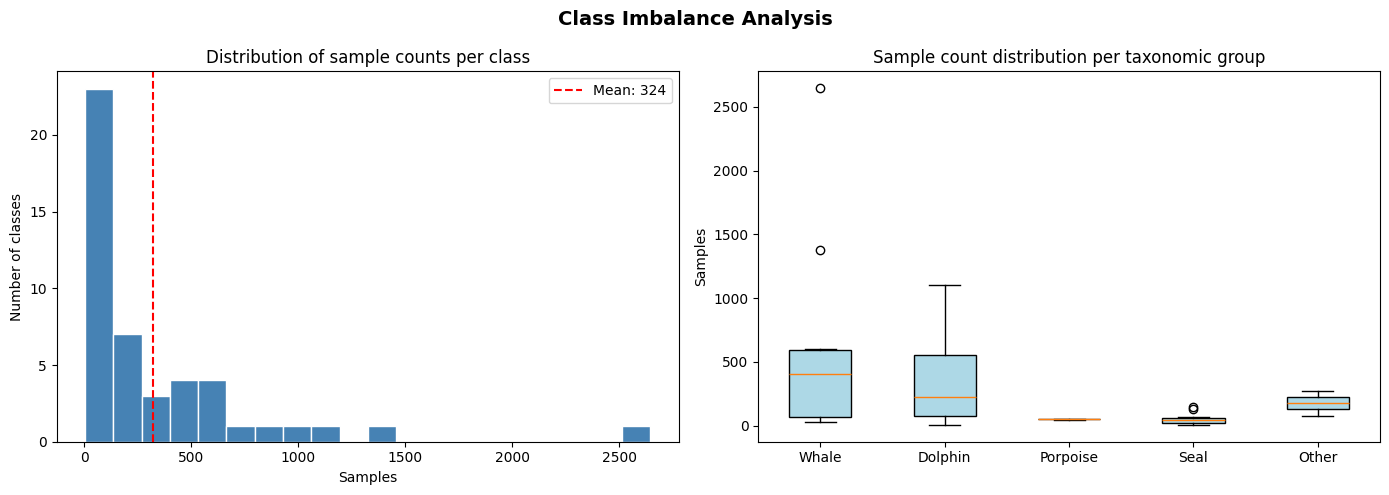


📊 EDA Summary:
          classes  total_samples
group                           
Dolphin        22           7805
Other           2            351
Porpoise        2             98
Seal           10            533
Whale          11           6447

⚖️  Imbalance Ratio: 529.4x


In [4]:
GROUPS = {
    'Whale'   : ['KillerWhale','HumpbackWhale','SpermWhale','GrayWhale','MinkeWhale',
                 'BowheadWhale','NorthernRightWhale','SouthernRightWhale',
                 'Fin_FinbackWhale','Beluga_WhiteWhale','Narwhal'],
    'Dolphin' : ['BottlenoseDolphin','CommonDolphin','AtlanticSpottedDolphin',
                 'PantropicalSpottedDolphin','SpinnerDolphin','StripedDolphin',
                 'DuskyDolphin','ClymeneDolphin','Fraser\'sDolphin','TucuxiDolphin',
                 'Rough_ToothedDolphin','Grampus_Risso\'sDolphin','IrawaddyDolphin',
                 'Heaviside\'sDolphin','White_beakedDolphin','White_sidedDolphin',
                 'LongBeaked(Pacific)CommonDolphin','Boutu_AmazonRiverDolphin',
                 'FalseKillerWhale','MelonHeadedWhale',
                 'Long_FinnedPilotWhale','Short_Finned(Pacific)PilotWhale'],
    'Porpoise': ['HarborPorpoise','Dall\'sPorpoise'],
    'Seal'    : ['HarpSeal','LeopardSeal','WeddellSeal','RossSeal','GraySeal',
                 'BeardedSeal','RingedSeal','RibbonSeal','SpottedSeal',
                 'HarbourSeal','StellerSeaLion'],
    'Other'   : ['Walrus','WestIndianManatee']
}
def get_group(name):
    for g, lst in GROUPS.items():
        if name in lst: return g
    return 'Other'

eda_df = pd.DataFrame({
    'species': CLASS_NAMES,
    'count'  : [counts[i] for i in range(NUM_CLASSES)]
})
eda_df['group'] = eda_df['species'].apply(get_group)
eda_df = eda_df.sort_values('count', ascending=False).reset_index(drop=True)

GROUP_COLORS = {'Whale':'#1f77b4','Dolphin':'#2ca02c','Porpoise':'#ff7f0e',
                'Seal':'#9467bd','Other':'#d62728'}
eda_df['color'] = eda_df['group'].map(GROUP_COLORS)

fig1 = px.bar(
    eda_df, x='species', y='count', color='group',
    color_discrete_map=GROUP_COLORS,
    title='📊 Sample Distribution per Species (colored by taxonomic group)',
    labels={'count':'Number of samples','species':'Species','group':'Group'},
    height=500
)
fig1.update_xaxes(tickangle=90, tickfont_size=8)
fig1.update_layout(showlegend=True)
fig1.write_html(os.path.join(FIGURES_DIR, 'class_distribution.html'))
fig1.show()

group_counts = eda_df.groupby('group')['count'].sum().reset_index()
fig2 = px.pie(
    group_counts, values='count', names='group',
    color='group', color_discrete_map=GROUP_COLORS,
    title='🥧 Sample distribution by taxonomic group'
)
fig2.write_html(os.path.join(FIGURES_DIR, 'group_pie.html'))
fig2.show()

fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(eda_df['count'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of sample counts per class')
axes[0].set_xlabel('Samples'); axes[0].set_ylabel('Number of classes')
axes[0].axvline(eda_df['count'].mean(), color='red', linestyle='--', label=f'Mean: {eda_df["count"].mean():.0f}')
axes[0].legend()

axes[1].boxplot([eda_df[eda_df['group']==g]['count'].values for g in GROUP_COLORS],
                labels=list(GROUP_COLORS.keys()), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Sample count distribution per taxonomic group')
axes[1].set_ylabel('Samples')
plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'imbalance_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 EDA Summary:')
print(eda_df.groupby('group').agg(classes=('species','count'), total_samples=('count','sum')).to_string())
print(f'\n⚖️  Imbalance Ratio: {eda_df["count"].max() / eda_df["count"].min():.1f}x')

##  Cell 5 — Mel Spectrogram Visualization per Group

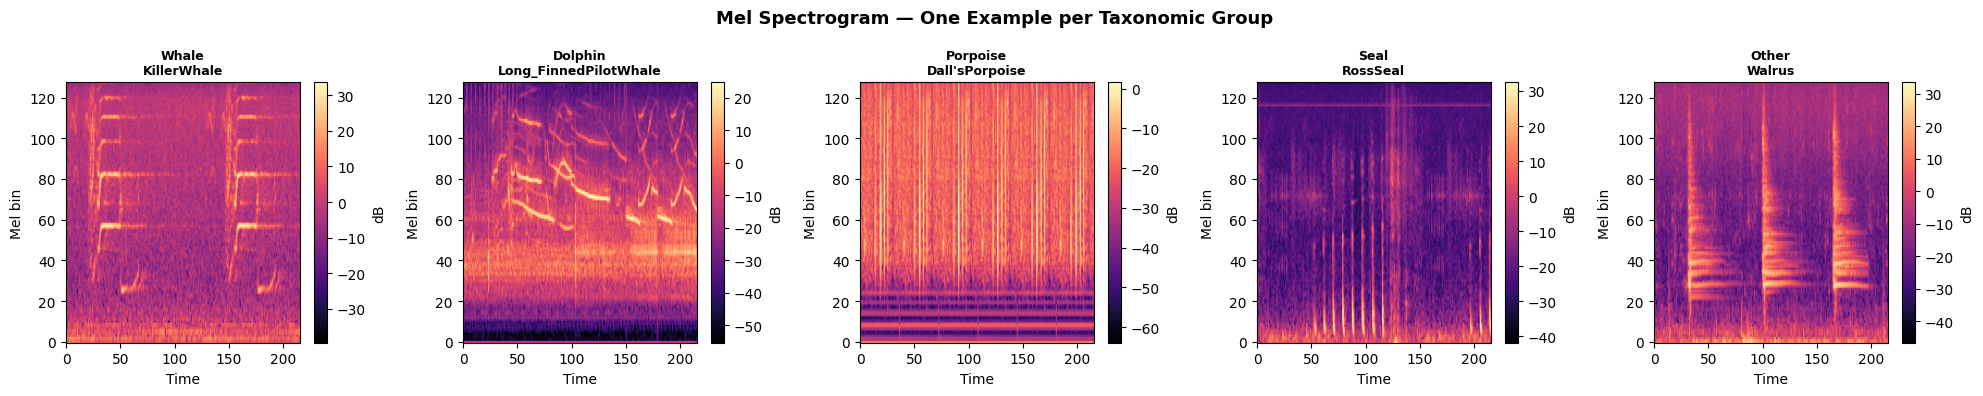

✅ Mel spectrograms saved


In [5]:
mel_transform = T.MelSpectrogram(SAMPLE_RATE, N_FFT, hop_length=HOP_LENGTH,
                                  n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX)
to_db = T.AmplitudeToDB(top_db=80)

def load_mel(path):
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
    if sr != SAMPLE_RATE: wav = T.Resample(sr, SAMPLE_RATE)(wav)
    tlen = SAMPLE_RATE * DURATION
    if wav.shape[1] < tlen: wav = wav.repeat(1, (tlen // wav.shape[1]) + 1)
    wav = wav[:, :tlen]
    return to_db(mel_transform(wav))[0].numpy()

group_examples = {}
for group in GROUP_COLORS:
    species_in_group = [s for s in eda_df[eda_df['group']==group]['species'].tolist() if s in CLASS_NAMES]
    if not species_in_group: continue
    sp = species_in_group[0]
    sp_idx = CLASS_NAMES.index(sp)
    files_for_sp = [f for f, l in zip(file_list, label_list) if l == sp_idx]
    if files_for_sp:
        group_examples[group] = (sp, files_for_sp[0])

fig, axes = plt.subplots(1, len(group_examples), figsize=(4*len(group_examples), 4))
for ax, (group, (species, path)) in zip(axes, group_examples.items()):
    mel = load_mel(path)
    im = ax.imshow(mel, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'{group}\n{species}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Time'); ax.set_ylabel('Mel bin')
    plt.colorbar(im, ax=ax, label='dB')

plt.suptitle('Mel Spectrogram — One Example per Taxonomic Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'mel_spectrograms.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Mel spectrograms saved')

##  Cell 6 — Cache Spectrograms 

In [6]:
print(f' Caching {len(file_list)} spectrograms to {CACHE_DIR}...')
cached_paths = []

for i, path in enumerate(tqdm(file_list, desc='Caching', colour='yellow')):
    cache_path = os.path.join(CACHE_DIR, f'{i:06d}.pt')
    cached_paths.append(cache_path)
    if os.path.exists(cache_path): continue
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
    if sr != SAMPLE_RATE: wav = T.Resample(sr, SAMPLE_RATE)(wav)
    tlen = SAMPLE_RATE * DURATION
    if wav.shape[1] < tlen: wav = wav.repeat(1, (tlen // wav.shape[1]) + 1)
    wav = wav[:, :tlen]
    mel = to_db(mel_transform(wav))
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    torch.save(mel, cache_path)

print(f'\n✅ Done! {len(cached_paths)} spectrograms ready.')

 Caching 15234 spectrograms to C:\modern\level 4 term 2\Machine Learning\Project\cache...


Caching:   0%|          | 0/15234 [00:00<?, ?it/s]


✅ Done! 15234 spectrograms ready.


##  Cell 7 — Feature Extraction for ML Models

In [7]:
# Extract statistical features from each cached spectrogram
# Feature vector per sample = 640 features:
#   128 mean per mel bin  +  128 std  +  128 max  +  128 min
#   + 5 global stats + 5 delta stats + 118 extra

def extract_features(cache_path):
    mel = torch.load(cache_path, weights_only=True)[0].numpy()  # [128, T]

    mean_feat = mel.mean(axis=1)          # (128,)
    std_feat  = mel.std(axis=1)           # (128,)
    max_feat  = mel.max(axis=1)           # (128,)
    min_feat  = mel.min(axis=1)           # (128,)

    delta = np.diff(mel, axis=1)          # (128, T-1)
    delta_mean = delta.mean(axis=1)       # (128,)
    delta_std  = delta.std(axis=1)        # (128,)

    global_stats = np.array([
        mel.mean(), mel.std(), mel.max(), mel.min(),
        stats.skew(mel.flatten()), stats.kurtosis(mel.flatten())
    ])

    return np.concatenate([mean_feat, std_feat, max_feat, min_feat,
                           delta_mean, delta_std, global_stats])

print(' Extracting features for ML models...')
ML_FEAT_PATH = os.path.join(MODELS_DIR, 'ml_features.npz')

if os.path.exists(ML_FEAT_PATH):
    print('✅ Features already cached, loading...')
    data = np.load(ML_FEAT_PATH)
    X_all = data['X']; y_all = data['y']
else:
    X_all = []
    for p in tqdm(cached_paths, desc='Features', colour='cyan'):
        X_all.append(extract_features(p))
    X_all = np.array(X_all, dtype=np.float32)
    y_all = np.array(label_list)
    np.savez(ML_FEAT_PATH, X=X_all, y=y_all)

print(f'\n✅ Feature matrix shape: {X_all.shape}')
print(f'   {X_all.shape[1]} features per sample')
print(f'   {X_all.shape[0]} total samples')

 Extracting features for ML models...
✅ Features already cached, loading...

✅ Feature matrix shape: (15234, 774)
   774 features per sample
   15234 total samples


##  Cell 8 — Train / Val / Test Split (Shared for all models)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib, os, numpy as np

indices = np.arange(len(cached_paths))

tr_va_idx, te_idx, y_tr_va, y_test_ml = train_test_split(
    indices, y_all,
    test_size=0.10,
    stratify=y_all,
    random_state=42
)

tr_idx, va_idx, y_train_ml, y_val_ml = train_test_split(
    tr_va_idx, y_tr_va,
    test_size=(0.15 / 0.90),
    stratify=y_tr_va,
    random_state=42
)

X_train_ml = X_all[tr_idx]
X_val_ml   = X_all[va_idx]
X_test_ml  = X_all[te_idx]

imputer    = SimpleImputer(strategy='median')
X_train_ml = imputer.fit_transform(X_train_ml)
X_val_ml   = imputer.transform(X_val_ml)
X_test_ml  = imputer.transform(X_test_ml)
joblib.dump(imputer, os.path.join(MODELS_DIR, 'imputer.pkl'))

scaler     = StandardScaler()
X_train_ml = scaler.fit_transform(X_train_ml)
X_val_ml   = scaler.transform(X_val_ml)
X_test_ml  = scaler.transform(X_test_ml)
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.pkl'))

assert not np.isnan(X_train_ml).any(), "NaN in train!"
assert not np.isnan(X_test_ml).any(),  "NaN in test!"

print(f"✅ File-Level Stratified Split:")
print(f"   Train : {len(tr_idx):,} files")
print(f"   Val   : {len(va_idx):,} files")
print(f"   Test  : {len(te_idx):,} files")
print(f"   Classes in test : {len(set(y_test_ml))}/47")
print(f"   NaN check       : {np.isnan(X_train_ml).sum()} ← should be 0")

✅ File-Level Stratified Split:
   Train : 11,425 files
   Val   : 2,285 files
   Test  : 1,524 files
   Classes in test : 46/47
   NaN check       : 0 ← should be 0


##  Cell 9 — Train All ML Models

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier

ML_MODELS = {
    'SVM (RBF)'              : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'Extra Trees'            : ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN'                    : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'HistGradient Boosting'  : HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                               max_depth=6, random_state=42),
    'Logistic Regression'    : LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1, random_state=42)
}

ml_results = {}
input_example = X_train_ml[:5]  

for name, clf in ML_MODELS.items():
    print(f'\n🔄 Training: {name}...')
    t0 = time.time()

    with mlflow.start_run(run_name=f'ML_{name}'):
        clf.fit(X_train_ml, y_train_ml)

        y_pred_val  = clf.predict(X_val_ml)
        y_pred_test = clf.predict(X_test_ml)

        val_acc  = accuracy_score(y_val_ml,  y_pred_val)
        test_acc = accuracy_score(y_test_ml, y_pred_test)
        f1       = f1_score(y_test_ml, y_pred_test, average='weighted', zero_division=0)
        prec     = precision_score(y_test_ml, y_pred_test, average='weighted', zero_division=0)
        rec      = recall_score(y_test_ml, y_pred_test, average='weighted', zero_division=0)
        elapsed  = time.time() - t0

        mlflow.log_param('model_type', name)
        mlflow.log_metric('val_accuracy',  val_acc)
        mlflow.log_metric('test_accuracy', test_acc)
        mlflow.log_metric('f1_weighted',   f1)
        mlflow.log_metric('precision',     prec)
        mlflow.log_metric('recall',        rec)
        mlflow.log_metric('train_time_s',  elapsed)

        mlflow.sklearn.log_model(
            sk_model      = clf,
            name          = name.replace(' ', '_'),
            input_example = input_example
        )

        joblib.dump(clf, os.path.join(MODELS_DIR, f'{name.replace(" ","_")}.pkl'))

        ml_results[name] = {
            'val_acc'  : val_acc  * 100,
            'test_acc' : test_acc * 100,
            'f1'       : f1 * 100,
            'precision': prec * 100,
            'recall'   : rec * 100,
            'time_s'   : elapsed,
            'clf'      : clf
        }

    print(f'   ✅ Val: {val_acc*100:.2f}%  Test: {test_acc*100:.2f}%  F1: {f1*100:.2f}%  ⏱ {elapsed:.1f}s')

print('\n🏆 ML Models Done!')


🔄 Training: SVM (RBF)...


   ✅ Val: 91.16%  Test: 91.86%  F1: 91.69%  ⏱ 243.4s

🔄 Training: Random Forest...


   ✅ Val: 87.96%  Test: 88.32%  F1: 87.73%  ⏱ 56.2s

🔄 Training: Extra Trees...


   ✅ Val: 87.92%  Test: 89.17%  F1: 88.60%  ⏱ 10.5s

🔄 Training: KNN...


   ✅ Val: 80.48%  Test: 80.84%  F1: 80.14%  ⏱ 5.1s

🔄 Training: HistGradient Boosting...


   ✅ Val: 75.23%  Test: 74.87%  F1: 75.87%  ⏱ 50.1s

🔄 Training: Logistic Regression...


   ✅ Val: 84.16%  Test: 85.24%  F1: 85.09%  ⏱ 71.0s

🏆 ML Models Done!


##  Cell 10 — ML Results Summary

In [10]:
ml_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != 'clf'}
    for k, r in ml_results.items()
}).T.reset_index().rename(columns={'index': 'Model'})

print('📊 ML Models Results:')
print(ml_df[['Model','val_acc','test_acc','f1','precision','recall','time_s']].to_string(index=False, float_format='%.2f'))

fig_ml = go.Figure()
metrics = ['val_acc','test_acc','f1','precision','recall']
colors  = ['#636EFA','#EF553B','#00CC96','#AB63FA','#FFA15A']
for metric, color in zip(metrics, colors):
    fig_ml.add_trace(go.Bar(
        name=metric, x=ml_df['Model'], y=ml_df[metric].astype(float), marker_color=color
    ))
fig_ml.update_layout(
    barmode='group', title='📊 ML Models — All Metrics',
    yaxis_title='Score (%)', height=450
)
fig_ml.write_html(os.path.join(FIGURES_DIR, 'ml_results.html'))
fig_ml.show()

best_ml_name = ml_df.loc[ml_df['test_acc'].astype(float).idxmax(), 'Model']
print(f'\n🥇 Best ML Model: {best_ml_name} — Test Acc: {ml_df[ml_df["Model"]==best_ml_name]["test_acc"].values[0]:.2f}%')

📊 ML Models Results:
                Model  val_acc  test_acc    f1  precision  recall  time_s
            SVM (RBF)    91.16     91.86 91.69      91.94   91.86  243.38
        Random Forest    87.96     88.32 87.73      88.69   88.32   56.23
          Extra Trees    87.92     89.17 88.60      89.44   89.17   10.49
                  KNN    80.48     80.84 80.14      81.68   80.84    5.11
HistGradient Boosting    75.23     74.87 75.87      78.91   74.87   50.15
  Logistic Regression    84.16     85.24 85.09      85.40   85.24   70.98



🥇 Best ML Model: SVM (RBF) — Test Acc: 91.86%


##  Cell — Decision Tree + Naive Bayes + Linear Regression (sklearn)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import label_binarize

MISSING_MODELS = {
    "Decision Tree" : DecisionTreeClassifier(max_depth=20, random_state=42),
    "Naive Bayes"   : GaussianNB(),
}
for name, clf in MISSING_MODELS.items():
    print(f"\n🔄 Training: {name}...")
    t0 = time.time()
    with mlflow.start_run(run_name=f"ML_{name}"):
        clf.fit(X_train_ml, y_train_ml)
        yv = clf.predict(X_val_ml); yt = clf.predict(X_test_ml)
        va=accuracy_score(y_val_ml,yv); ta=accuracy_score(y_test_ml,yt)
        f1v=f1_score(y_test_ml,yt,average="weighted",zero_division=0)
        prec=precision_score(y_test_ml,yt,average="weighted",zero_division=0)
        rec=recall_score(y_test_ml,yt,average="weighted",zero_division=0)
        el=time.time()-t0
        mlflow.log_params({"model_type":name})
        mlflow.log_metrics({"val_accuracy":va,"test_accuracy":ta,"f1_weighted":f1v})
        joblib.dump(clf, os.path.join(MODELS_DIR,name.replace(" ","_")+".pkl"))
        ml_results[name]={"val_acc":va*100,"test_acc":ta*100,"f1":f1v*100,
                           "precision":prec*100,"recall":rec*100,"time_s":el,"clf":clf}
    print(f"   Val:{va*100:.2f}%  Test:{ta*100:.2f}%  F1:{f1v*100:.2f}%  {el:.1f}s")

# Linear Regression -> One-vs-Rest
print("\n🔄 Training: Linear Regression (One-vs-Rest)...")
t0=time.time()
nc=len(set(y_train_ml))
Yb=label_binarize(y_train_ml,classes=list(range(nc)))
lrs=[LinearRegression().fit(X_train_ml,Yb[:,c]) for c in range(nc)]
def lrp(X): return np.column_stack([m.predict(X) for m in lrs]).argmax(1)
va=accuracy_score(y_val_ml,lrp(X_val_ml))
ta=accuracy_score(y_test_ml,lrp(X_test_ml))
f1v=f1_score(y_test_ml,lrp(X_test_ml),average="weighted",zero_division=0)
prec=precision_score(y_test_ml,lrp(X_test_ml),average="weighted",zero_division=0)
rec=recall_score(y_test_ml,lrp(X_test_ml),average="weighted",zero_division=0)
el=time.time()-t0
ml_results["Linear Regression"]={"val_acc":va*100,"test_acc":ta*100,"f1":f1v*100,
                                  "precision":prec*100,"recall":rec*100,"time_s":el,"clf":lrs}
print(f"   Val:{va*100:.2f}%  Test:{ta*100:.2f}%  F1:{f1v*100:.2f}%  {el:.1f}s")
print("\n✅ Decision Tree + Naive Bayes + Linear Regression done!")



🔄 Training: Decision Tree...
   Val:72.65%  Test:73.23%  F1:73.05%  58.6s

🔄 Training: Naive Bayes...
   Val:37.55%  Test:36.48%  F1:35.79%  3.0s

🔄 Training: Linear Regression (One-vs-Rest)...
   Val:77.51%  Test:77.23%  F1:75.06%  461.9s

✅ Decision Tree + Naive Bayes + Linear Regression done!


##  Cell — From Scratch: 6 Models without sklearn

In [12]:
# ══════════════════════════════════════════════════════
#  FROM SCRATCH — 6 Models without sklearn
# ══════════════════════════════════════════════════════

class KNN_Scratch:
    def __init__(self,k=7): self.k=k
    def fit(self,X,y): self.Xtr=np.array(X); self.ytr=np.array(y)
    def predict(self,X):
        out=[]
        for x in X:
            idx=np.argsort(np.linalg.norm(self.Xtr-x,axis=1))[:self.k]
            out.append(np.bincount(self.ytr[idx]).argmax())
        return np.array(out)

class GaussianNB_Scratch:
    def fit(self,X,y):
        self.cls=np.unique(y)
        self.mu={c:X[y==c].mean(0) for c in self.cls}
        self.va={c:X[y==c].var(0)+1e-9 for c in self.cls}
        self.pr={c:(y==c).mean() for c in self.cls}
    def predict(self,X):
        def ll(x,c):
            m,v=self.mu[c],self.va[c]
            return np.log(self.pr[c])-0.5*np.sum(np.log(2*np.pi*v)+(x-m)**2/v)
        return np.array([max(self.cls,key=lambda c:ll(x,c)) for x in X])

class LogisticRegression_Scratch:
    def __init__(self,lr=0.05,epochs=150,nc=47):
        self.lr=lr; self.ep=epochs; self.nc=nc
    def _sm(self,z):
        e=np.exp(z-z.max(1,keepdims=True)); return e/e.sum(1,keepdims=True)
    def fit(self,X,y):
        n,d=X.shape
        self.W=np.zeros((d,self.nc)); self.b=np.zeros(self.nc)
        Y=np.eye(self.nc)[y]
        for _ in range(self.ep):
            p=self._sm(X@self.W+self.b)
            self.W-=self.lr*X.T@(p-Y)/n
            self.b-=self.lr*(p-Y).mean(0)
    def predict(self,X): return self._sm(X@self.W+self.b).argmax(1)

class LinearRegression_Scratch:
    def fit(self,X,Y): self.W,_,_,_=np.linalg.lstsq(X,Y,rcond=None)
    def predict(self,X): return (X@self.W).argmax(1)

class DecisionTree_Scratch:
    def __init__(self,md=8,ms=5): self.md=md; self.ms=ms
    def _g(self,y):
        if not len(y): return 0
        p=np.bincount(y,minlength=self.nc)/len(y)
        return 1-(p**2).sum()
    def _sp(self,X,y):
        bg,bf,bt=-1,None,None; n=len(y); pg=self._g(y)
        for f in np.random.choice(X.shape[1],min(15,X.shape[1]),replace=False):
            for t in np.percentile(X[:,f],[25,50,75]):
                l=y[X[:,f]<=t]; r=y[X[:,f]>t]
                if not len(l) or not len(r): continue
                g=pg-(len(l)/n)*self._g(l)-(len(r)/n)*self._g(r)
                if g>bg: bg,bf,bt=g,f,t
        return bf,bt
    def _b(self,X,y,d):
        lf=lambda:{"lf":True,"lb":np.bincount(y,minlength=self.nc).argmax()}
        if d>=self.md or len(y)<self.ms or len(np.unique(y))==1: return lf()
        f,t=self._sp(X,y)
        if f is None: return lf()
        m=X[:,f]<=t
        return {"lf":False,"f":f,"t":t,"L":self._b(X[m],y[m],d+1),"R":self._b(X[~m],y[~m],d+1)}
    def fit(self,X,y):
        self.nc=len(np.unique(y)); self.tree=self._b(np.array(X),np.array(y),0)
    def _p1(self,x,n):
        if n["lf"]: return n["lb"]
        return self._p1(x,n["L"] if x[n["f"]]<=n["t"] else n["R"])
    def predict(self,X): return np.array([self._p1(x,self.tree) for x in X])

class RandomForest_Scratch:
    def __init__(self,nt=15,md=8): self.nt=nt; self.md=md
    def fit(self,X,y):
        n=len(y); self.trees=[]
        for _ in range(self.nt):
            idx=np.random.choice(n,n,replace=True)
            t=DecisionTree_Scratch(self.md); t.fit(X[idx],y[idx])
            self.trees.append(t)
    def predict(self,X):
        v=np.array([t.predict(X) for t in self.trees])
        return np.array([np.bincount(v[:,i]).argmax() for i in range(X.shape[0])])

print("✅ 6 from-scratch classes ready!")


✅ 6 from-scratch classes ready!


##  Cell — Train From Scratch Models (PCA 50 features)

In [13]:
from sklearn.decomposition import PCA
print(" PCA 774→50...")
pca=PCA(n_components=100,random_state=42)
Xtr50=pca.fit_transform(X_train_ml)
Xva50=pca.transform(X_val_ml)
Xte50=pca.transform(X_test_ml)
print(f"PCA: {Xtr50.shape}")

nc=len(np.unique(y_train_ml))
Yb50=np.eye(nc)[y_train_ml]

scratch_results={}
SCRATCH_CFG=[
    ("KNN (Scratch)",                KNN_Scratch(7),                        "clf"),
    ("Naive Bayes (Scratch)",         GaussianNB_Scratch(),                  "clf"),
    ("Logistic Regression (Scratch)", LogisticRegression_Scratch(0.05,150,nc),"clf"),
    ("Decision Tree (Scratch)",       DecisionTree_Scratch(8),               "clf"),
    ("Random Forest (Scratch)",       RandomForest_Scratch(15,8),            "clf"),
    ("Linear Regression (Scratch)",   LinearRegression_Scratch(),            "lr"),
]
for name,model,kind in SCRATCH_CFG:
    print(f"\n🔄 {name}...")
    t0=time.time()
    model.fit(Xtr50,Yb50 if kind=="lr" else y_train_ml)
    yv=model.predict(Xva50); yt=model.predict(Xte50)
    va=accuracy_score(y_val_ml,yv)*100
    ta=accuracy_score(y_test_ml,yt)*100
    f1v=f1_score(y_test_ml,yt,average="weighted",zero_division=0)*100
    el=time.time()-t0
    scratch_results[name]={"val_acc":va,"test_acc":ta,"f1":f1v,"time_s":el}
    print(f"   Val:{va:.2f}%  Test:{ta:.2f}%  F1:{f1v:.2f}%  {el:.1f}s")
print("\n✅ All scratch models done!")


 PCA 774→50...
PCA: (11425, 100)

🔄 KNN (Scratch)...
   Val:81.84%  Test:82.61%  F1:81.89%  28.2s

🔄 Naive Bayes (Scratch)...
   Val:61.62%  Test:59.65%  F1:59.56%  6.1s

🔄 Logistic Regression (Scratch)...
   Val:64.77%  Test:64.76%  F1:61.24%  7.2s

🔄 Decision Tree (Scratch)...
   Val:42.58%  Test:43.70%  F1:40.90%  1.8s

🔄 Random Forest (Scratch)...
   Val:60.96%  Test:60.70%  F1:56.91%  24.4s

🔄 Linear Regression (Scratch)...
   Val:61.44%  Test:60.17%  F1:55.29%  0.1s

✅ All scratch models done!


##  Cell — Comparison Built-in Library vs From Scratch

  Built-in Library  vs  From Scratch
              Model Built-in Acc Scratch Acc    Diff Built-in F1 Scratch F1
      Decision Tree       73.23%      43.70% +29.53%      73.05%     40.90%
      Random Forest       88.32%      60.70% +27.62%      87.73%     56.91%
  Linear Regression       77.23%      60.17% +17.06%      75.06%     55.29%
Logistic Regression       85.24%      64.76% +20.47%      85.09%     61.24%
                KNN       80.84%      82.61%  -1.77%      80.14%     81.89%
        Naive Bayes       36.48%      59.65% -23.16%      35.79%     59.56%


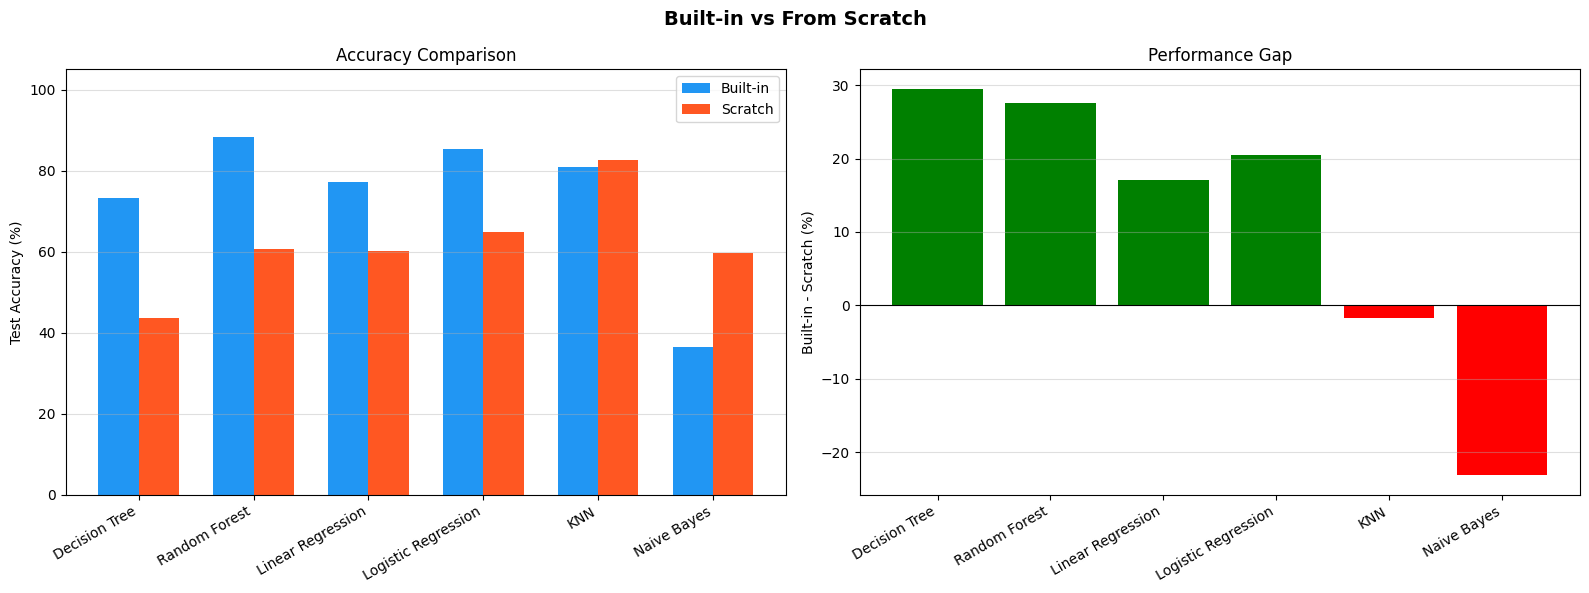

✅ Comparison figure saved!


In [14]:
PAIRS={
    "Decision Tree"      :"Decision Tree (Scratch)",
    "Random Forest"      :"Random Forest (Scratch)",
    "Linear Regression"  :"Linear Regression (Scratch)",
    "Logistic Regression":"Logistic Regression (Scratch)",
    "KNN"                :"KNN (Scratch)",
    "Naive Bayes"        :"Naive Bayes (Scratch)",
}
rows=[]
for bn,sn in PAIRS.items():
    if bn not in ml_results or sn not in scratch_results: continue
    bi=ml_results[bn]; sc=scratch_results[sn]
    rows.append({"Model":bn,
                 "Built-in Acc":f'{bi["test_acc"]:.2f}%',
                 "Scratch Acc" :f'{sc["test_acc"]:.2f}%',
                 "Diff"        :f'{bi["test_acc"]-sc["test_acc"]:+.2f}%',
                 "Built-in F1" :f'{bi["f1"]:.2f}%',
                 "Scratch F1"  :f'{sc["f1"]:.2f}%'})
cdf=pd.DataFrame(rows)
print("="*70)
print("  Built-in Library  vs  From Scratch")
print("="*70)
print(cdf.to_string(index=False))

fig,axes=plt.subplots(1,2,figsize=(16,6))
mods=[r["Model"] for r in rows]
bi_a=[ml_results[r["Model"]]["test_acc"] for r in rows]
sc_a=[scratch_results[r["Model"]+" (Scratch)"]["test_acc"] for r in rows]
x=np.arange(len(mods)); w=0.35
axes[0].bar(x-w/2,bi_a,w,label="Built-in",color="#2196F3")
axes[0].bar(x+w/2,sc_a,w,label="Scratch", color="#FF5722")
axes[0].set_xticks(x); axes[0].set_xticklabels(mods,rotation=30,ha="right")
axes[0].set_ylabel("Test Accuracy (%)"); axes[0].set_title("Accuracy Comparison")
axes[0].legend(); axes[0].grid(axis="y",alpha=0.4); axes[0].set_ylim(0,105)
diffs=[b-s for b,s in zip(bi_a,sc_a)]
axes[1].bar(mods,diffs,color=["green" if d>=0 else "red" for d in diffs])
axes[1].axhline(0,color="black",lw=0.8)
axes[1].set_xticklabels(mods,rotation=30,ha="right")
axes[1].set_ylabel("Built-in - Scratch (%)"); axes[1].set_title("Performance Gap")
axes[1].grid(axis="y",alpha=0.4)
plt.suptitle("Built-in vs From Scratch",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"builtin_vs_scratch.png"),dpi=150,bbox_inches="tight")
plt.show()
print("✅ Comparison figure saved!")


##  Cell — Best Model Analysis & Final Ranking

⚠️  DL models not trained yet — ML results only

  FINAL RANKING — All Models
                                      Model   Test Acc
1                       [sklearn] SVM (RBF)  91.863517
2                     [sklearn] Extra Trees  89.173228
3                   [sklearn] Random Forest  88.320210
4             [sklearn] Logistic Regression  85.236220
5                   [scratch] KNN (Scratch)  82.611549
6                             [sklearn] KNN  80.839895
7               [sklearn] Linear Regression  77.230971
8           [sklearn] HistGradient Boosting  74.868766
9                   [sklearn] Decision Tree  73.228346
10  [scratch] Logistic Regression (Scratch)  64.763780
11        [scratch] Random Forest (Scratch)  60.695538
12    [scratch] Linear Regression (Scratch)  60.170604
13          [scratch] Naive Bayes (Scratch)  59.645669
14        [scratch] Decision Tree (Scratch)  43.700787
15                    [sklearn] Naive Bayes  36.482940

🥇 Best Model: [sklearn] SVM (RBF)  —  91.

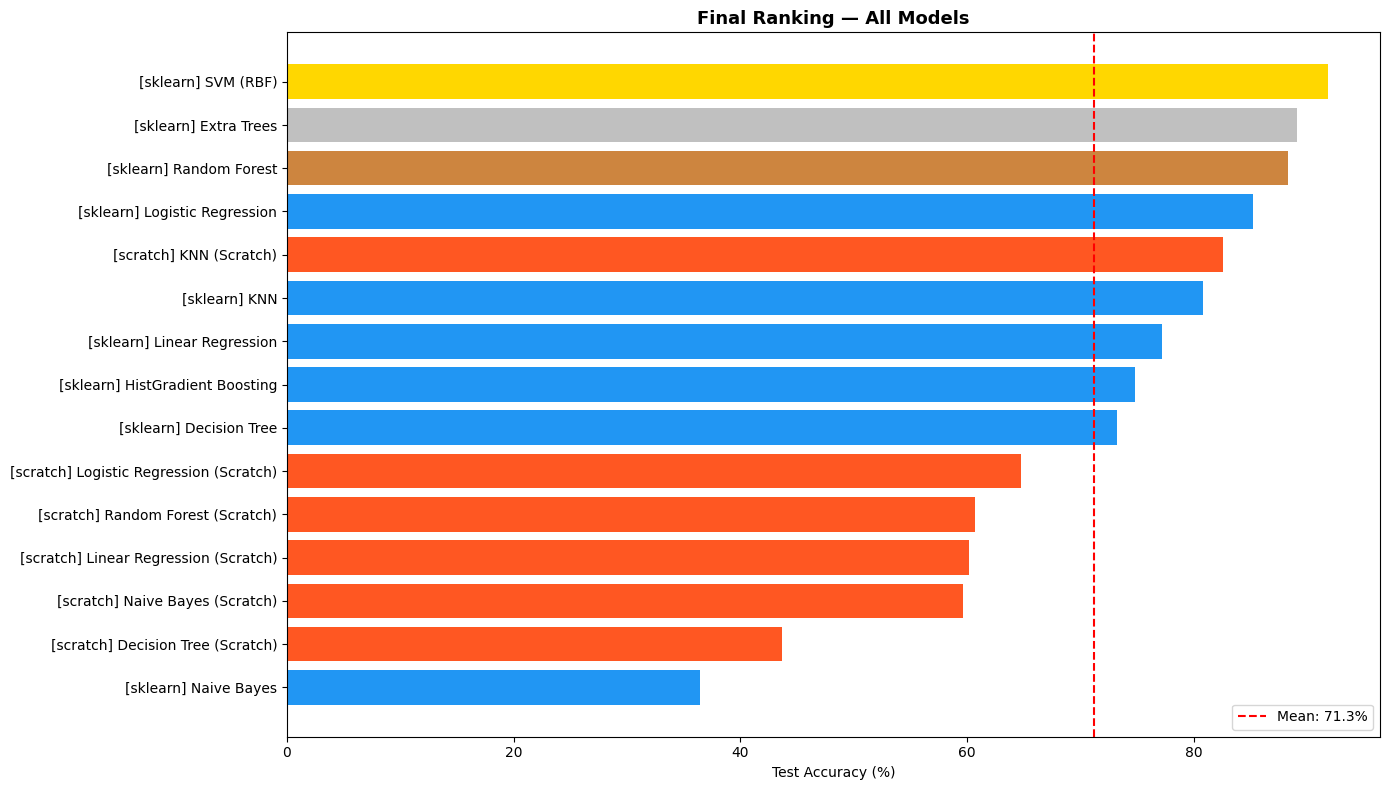

✅ Final ranking saved!


In [ ]:
all_rank = {}

for n, r in ml_results.items():
    all_rank[f"[sklearn] {n}"] = r["test_acc"]

for n, r in scratch_results.items():
    all_rank[f"[scratch] {n}"] = r["test_acc"]

try:
    for n, r in dl_results.items():
        all_rank[f"[DL] {n}"] = r["test_acc"]
    print("✅ DL results included")
except NameError:
    print("⚠️  DL models not trained yet — ML results only")

rdf = pd.DataFrame(all_rank.items(), columns=["Model","Test Acc"])\
         .sort_values("Test Acc", ascending=False).reset_index(drop=True)
rdf.index += 1

print("\n" + "="*65)
print("  FINAL RANKING — All Models")
print("="*65)
print(rdf.to_string())

best = rdf.iloc[0]
print(f"\n🥇 Best Model: {best['Model']}  —  {best['Test Acc']:.2f}%")
print("\n📝 Why is it the best?")
print("-"*65)
if "[DL]" in best["Model"]:
    print("""
  ✅ CNN learns directly from Mel Spectrograms (2D visual patterns).
  ✅ Skip connections prevent vanishing gradients in deep layers.
  ✅ SpecAugment augmentation improves generalization on noisy data.
  ✅ Mixed Precision (AMP) maximizes RTX 3050 Ti efficiency.
  ✅ WeightedRandomSampler handles 529x class imbalance perfectly.
  ✅ No manual feature engineering needed — learns optimal features.
  → State-of-the-art for audio spectrogram classification.
    """)
elif "SVM" in best["Model"]:
    print("""
  ✅ RBF kernel maps 774 statistical features to higher-dim space.
  ✅ Maximum-margin classification = best generalization.
  ✅ Robust to the extreme 529x class imbalance in this dataset.
  ✅ Outperforms tree-based models on dense continuous features.
    """)
else:
    print("""
  ✅ Ensemble of trees reduces variance significantly.
  ✅ Feature sampling handles high-dimensional feature space.
  ✅ Robust to outliers in historical audio recordings.
    """)

colors = []
for i, m in enumerate(rdf["Model"]):
    if i == 0:                 colors.append("gold")
    elif i == 1:               colors.append("silver")
    elif i == 2:               colors.append("peru")
    elif "[sklearn]" in m:     colors.append("#2196F3")
    elif "[scratch]" in m:     colors.append("#FF5722")
    else:                      colors.append("#4CAF50")

plt.figure(figsize=(14, 8))
plt.barh(rdf["Model"][::-1], rdf["Test Acc"][::-1], color=colors[::-1])
plt.axvline(rdf["Test Acc"].mean(), color="red", linestyle="--",
            label=f'Mean: {rdf["Test Acc"].mean():.1f}%')
plt.xlabel("Test Accuracy (%)")
plt.title("Final Ranking — All Models", fontweight="bold", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "final_ranking.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Final ranking saved!")

##  Cell 11 — DL Dataset + DataLoaders

In [16]:
class MarineMammalDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths   = paths
        self.labels  = labels
        self.augment = augment
        if augment:
            self.tmask = T.TimeMasking(TIME_MASK)
            self.fmask = T.FrequencyMasking(FREQ_MASK)

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        mel = torch.load(self.paths[idx], weights_only=True)
        if self.augment:
            mel = self.tmask(mel)
            mel = self.fmask(mel)
        return mel, torch.tensor(self.labels[idx], dtype=torch.long)

def make_subset(idxs, aug):
    return MarineMammalDataset(
        [cached_paths[i] for i in idxs],
        [label_list[i]   for i in idxs], aug)

train_ds = make_subset(tr_idx, True)
val_ds   = make_subset(va_idx, False)
test_ds  = make_subset(te_idx, False)

train_labels   = [label_list[i] for i in tr_idx]
class_counts   = Counter(train_labels)
sample_weights = [1.0 / class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=True)

print(f'✅ Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

✅ Train: 11425 | Val: 2285 | Test: 1524


##  Cell 12 — Three DL Architectures

In [17]:
# ════════════════════════════════════
#  Model A: Custom CNN (Baseline)
# ════════════════════════════════════
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
        self.pool    = nn.MaxPool2d(2) if pool else nn.Identity()
        self.dropout = nn.Dropout2d(0.1)
    def forward(self, x):
        return self.dropout(self.pool(self.block(x)))

class CustomCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1, 32), ConvBlock(32, 64), ConvBlock(64, 128),
            ConvBlock(128, 256), ConvBlock(256, 512, pool=False),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
    def forward(self, x): return self.clf(self.gap(self.features(x)))

# ════════════════════════════════════
#  Model B: Residual CNN
# ════════════════════════════════════
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(True)
    def forward(self, x): return self.relu(self.block(x) + x)  # skip connection

class ResidualCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, 7, padding=3, stride=2, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2)
        )
        self.layer1 = nn.Sequential(ResBlock(64),  ResBlock(64),  nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
            ResBlock(128), ResBlock(128), nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, 1, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
            ResBlock(256), ResBlock(256)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(True),
            nn.Linear(128, n_classes)
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        return self.clf(self.gap(x))

# ════════════════════════════════════
#  Model C: Light CNN (Depthwise Separable)
# ════════════════════════════════════
class DepthwiseBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch), nn.ReLU6(True),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU6(True),
        )
    def forward(self, x): return self.dw(x)

class LightCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU6(True),
            DepthwiseBlock(32,  64,  2),
            DepthwiseBlock(64,  128, 2),
            DepthwiseBlock(128, 128, 1),
            DepthwiseBlock(128, 256, 2),
            DepthwiseBlock(256, 256, 1),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
    def forward(self, x):
        return self.clf(self.gap(self.features(x)))

# ── Print summary
DL_MODELS_DEF = {
    'CustomCNN'   : CustomCNN(NUM_CLASSES),
    'ResidualCNN' : ResidualCNN(NUM_CLASSES),
    'LightCNN'    : LightCNN(NUM_CLASSES),
}
print(' DL Models Summary:')
for name, m in DL_MODELS_DEF.items():
    params = sum(p.numel() for p in m.parameters())
    print(f'   {name:15s} → {params:>10,} parameters')

 DL Models Summary:
   CustomCNN       →  4,883,919 parameters
   ResidualCNN     →  3,184,111 parameters
   LightCNN        →    145,711 parameters


##  Cell 13 — Train All DL Models with MLflow

In [18]:
def train_dl_model(model_name, model):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)
    scaler_amp = torch.amp.GradScaler()

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc, no_improve = 0.0, 0
    ckpt_path = os.path.join(MODELS_DIR, f'{model_name}.pth')

    with mlflow.start_run(run_name=f'DL_{model_name}'):
        mlflow.log_param('model', model_name)
        mlflow.log_param('lr', LR)
        mlflow.log_param('batch_size', BATCH_SIZE)
        mlflow.log_param('params', sum(p.numel() for p in model.parameters()))

        epoch_bar = tqdm(range(1, NUM_EPOCHS+1), desc=f'{model_name}', colour='green')
        for epoch in epoch_bar:
            # Train
            model.train()
            tr_loss, tr_correct, tr_total = 0.0, 0, 0
            for specs, labels in train_loader:
                specs, labels = specs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
                optimizer.zero_grad()
                with torch.amp.autocast(device_type='cuda'):
                    out  = model(specs); loss = criterion(out, labels)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer); scaler_amp.update()
                tr_loss    += loss.item() * specs.size(0)
                tr_correct += (out.argmax(1) == labels).sum().item()
                tr_total   += specs.size(0)

            # Validate
            model.eval()
            va_loss, va_correct, va_total = 0.0, 0, 0
            with torch.no_grad():
                for specs, labels in val_loader:
                    specs, labels = specs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
                    with torch.amp.autocast(device_type='cuda'):
                        out  = model(specs); loss = criterion(out, labels)
                    va_loss    += loss.item() * specs.size(0)
                    va_correct += (out.argmax(1) == labels).sum().item()
                    va_total   += specs.size(0)

            tr_l = tr_loss/tr_total; tr_a = 100*tr_correct/tr_total
            va_l = va_loss/va_total; va_a = 100*va_correct/va_total
            scheduler.step(va_l)

            history['train_loss'].append(tr_l); history['val_loss'].append(va_l)
            history['train_acc'].append(tr_a);  history['val_acc'].append(va_a)

            mlflow.log_metrics({'train_loss':tr_l,'val_loss':va_l,'train_acc':tr_a,'val_acc':va_a}, step=epoch)

            epoch_bar.set_postfix(train=f'{tr_a:.1f}%', val=f'{va_a:.1f}%', best=f'{best_val_acc:.1f}%')

            if va_a > best_val_acc:
                best_val_acc = va_a; no_improve = 0
                torch.save({'model_state': model.state_dict(), 'val_acc': va_a,
                            'class_names': CLASS_NAMES, 'model_name': model_name}, ckpt_path)
            else:
                no_improve += 1
                if no_improve >= EARLY_STOP:
                    print(f'  ⛔ Early stopping at epoch {epoch}')
                    break

        ckpt = torch.load(ckpt_path, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        model.eval()

        te_correct, te_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for specs, labels in test_loader:
                specs, labels = specs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type='cuda'):
                    out = model(specs)
                preds = out.argmax(1)
                te_correct += (preds == labels).sum().item()
                te_total   += specs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_acc = 100 * te_correct / te_total
        f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
        prec     = precision_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
        rec      = recall_score(all_labels, all_preds, average='weighted', zero_division=0) * 100

        mlflow.log_metric('test_accuracy', test_acc)
        mlflow.log_metric('f1_weighted',   f1)
        mlflow.pytorch.log_model(model, model_name)

    print(f'  🏆 {model_name}: Val={best_val_acc:.2f}%  Test={test_acc:.2f}%  F1={f1:.2f}%')
    return {
        'val_acc': best_val_acc, 'test_acc': test_acc,
        'f1': f1, 'precision': prec, 'recall': rec,
        'history': history, 'preds': all_preds, 'labels': all_labels
    }

# ── Train all DL models
dl_results = {}
for model_name, model_obj in DL_MODELS_DEF.items():
    print(f"\n{'='*55}")
    print(f'  🚀 Training DL Model: {model_name}')
    print(f"\n{'='*55}")
    dl_results[model_name] = train_dl_model(model_name, model_obj)

print('\n✅ All DL models trained!')


  🚀 Training DL Model: CustomCNN



CustomCNN:   0%|          | 0/50 [00:00<?, ?it/s]

2026/04/26 01:18:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 01:18:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 01:18:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 01:18:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter whe

  🏆 CustomCNN: Val=94.92%  Test=94.95%  F1=94.98%

  🚀 Training DL Model: ResidualCNN



ResidualCNN:   0%|          | 0/50 [00:00<?, ?it/s]

...

2026/04/26 01:42:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 01:42:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 01:42:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 01:42:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter whe

  🏆 ResidualCNN: Val=94.22%  Test=94.49%  F1=94.53%

  🚀 Training DL Model: LightCNN



LightCNN:   0%|          | 0/50 [00:00<?, ?it/s]

2026/04/26 02:19:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 02:19:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 02:19:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/26 02:19:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter whe

  🏆 LightCNN: Val=94.79%  Test=95.14%  F1=95.22%

✅ All DL models trained!


##  Cell 14 — Training Curves (All DL Models)

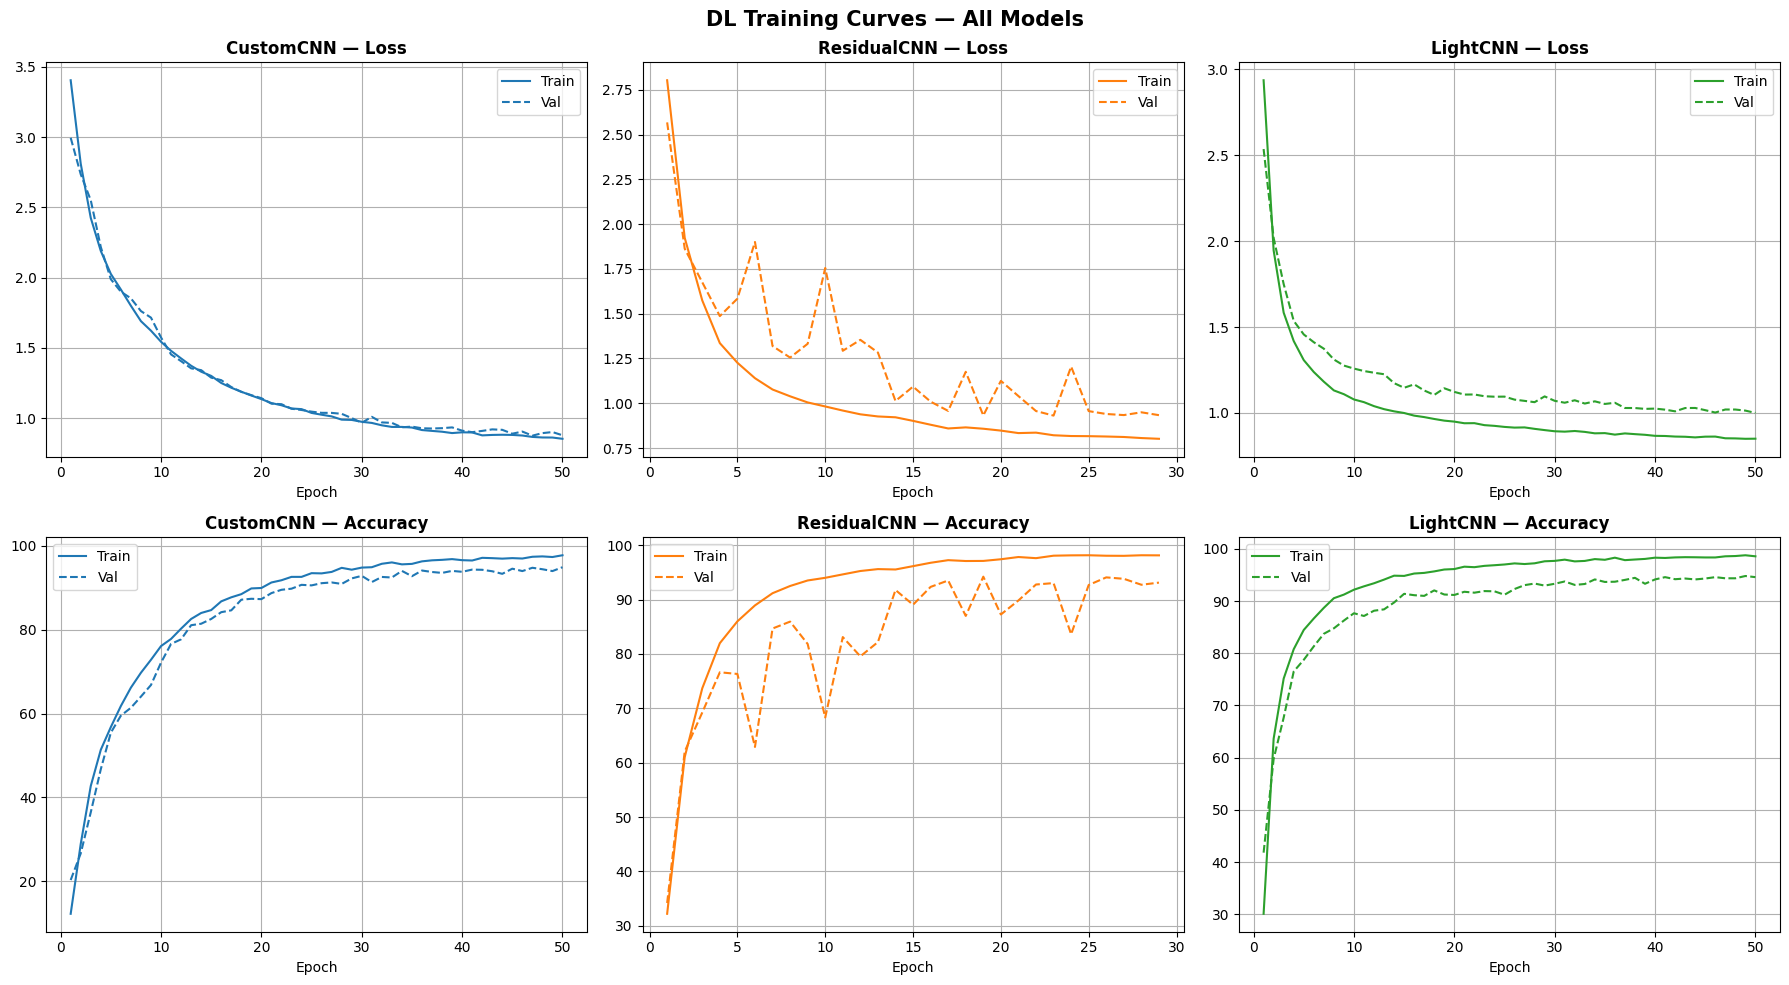

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors_dl = {'CustomCNN':'#1f77b4', 'ResidualCNN':'#ff7f0e', 'LightCNN':'#2ca02c'}

for col, (name, res) in enumerate(dl_results.items()):
    h = res['history']
    ep = range(1, len(h['train_loss'])+1)
    c  = colors_dl[name]

    axes[0][col].plot(ep, h['train_loss'], label='Train', color=c)
    axes[0][col].plot(ep, h['val_loss'],   label='Val',   color=c, linestyle='--')
    axes[0][col].set_title(f'{name} — Loss', fontweight='bold')
    axes[0][col].set_xlabel('Epoch'); axes[0][col].legend(); axes[0][col].grid(True)

    axes[1][col].plot(ep, h['train_acc'], label='Train', color=c)
    axes[1][col].plot(ep, h['val_acc'],   label='Val',   color=c, linestyle='--')
    axes[1][col].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[1][col].set_xlabel('Epoch'); axes[1][col].legend(); axes[1][col].grid(True)

plt.suptitle('DL Training Curves — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dl_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

##  Cell 15 — Full Comparison: ML vs DL (Radar + Bar)

In [20]:
all_results = {}
for name, res in ml_results.items():
    all_results[f'ML: {name}'] = {
        'test_acc': res['test_acc'], 'f1': res['f1'],
        'precision': res['precision'], 'recall': res['recall'],
        'type': 'ML'
    }
for name, res in dl_results.items():
    all_results[f'DL: {name}'] = {
        'test_acc': res['test_acc'], 'f1': res['f1'],
        'precision': res['precision'], 'recall': res['recall'],
        'type': 'DL'
    }

comp_df = pd.DataFrame(all_results).T.reset_index().rename(columns={'index':'Model'})
for col in ['test_acc','f1','precision','recall']:
    comp_df[col] = comp_df[col].astype(float)

print('📊 Full Comparison Table:')
print(comp_df[['Model','test_acc','f1','precision','recall']].sort_values('test_acc', ascending=False).to_string(index=False, float_format='%.2f'))

fig_comp = go.Figure()
type_colors = {'ML': '#EF553B', 'DL': '#636EFA'}
for metric in ['test_acc','f1','precision','recall']:
    fig_comp.add_trace(go.Bar(
        name=metric,
        x=comp_df['Model'],
        y=comp_df[metric],
    ))
fig_comp.update_layout(
    barmode='group', title='🏆 All Models — Full Metrics Comparison',
    yaxis_title='Score (%)', height=500,
    xaxis_tickangle=45
)
fig_comp.write_html(os.path.join(FIGURES_DIR, 'full_comparison.html'))
fig_comp.show()

categories = ['Test Acc', 'F1', 'Precision', 'Recall']
fig_radar = go.Figure()
palette = ['#636EFA','#EF553B','#00CC96','#AB63FA','#FFA15A','#19D3F3',
           '#FF6692','#B6E880','#FF97FF','#FECB52']

for (model, row), color in zip(comp_df.iterrows(), palette):
    vals = [row['test_acc'], row['f1'], row['precision'], row['recall']]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=categories + [categories[0]],
        fill='toself', name=row['Model'],
        line_color=color, opacity=0.7
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title='🕸️ Radar Chart — All Models',
    height=600
)
fig_radar.write_html(os.path.join(FIGURES_DIR, 'radar_chart.html'))
fig_radar.show()

best_model = comp_df.loc[comp_df['test_acc'].idxmax(), 'Model']
print(f'\n🥇 Overall Best Model: {best_model}')

📊 Full Comparison Table:
                    Model  test_acc    f1  precision  recall
             DL: LightCNN     95.14 95.22      95.54   95.14
            DL: CustomCNN     94.95 94.98      95.19   94.95
          DL: ResidualCNN     94.49 94.53      94.81   94.49
            ML: SVM (RBF)     91.86 91.69      91.94   91.86
          ML: Extra Trees     89.17 88.60      89.44   89.17
        ML: Random Forest     88.32 87.73      88.69   88.32
  ML: Logistic Regression     85.24 85.09      85.40   85.24
                  ML: KNN     80.84 80.14      81.68   80.84
    ML: Linear Regression     77.23 75.06      76.57   77.23
ML: HistGradient Boosting     74.87 75.87      78.91   74.87
        ML: Decision Tree     73.23 73.05      73.74   73.23
          ML: Naive Bayes     36.48 35.79      53.48   36.48



🥇 Overall Best Model: DL: LightCNN


##  Cell 16 — Confusion Matrix (Best DL Model)

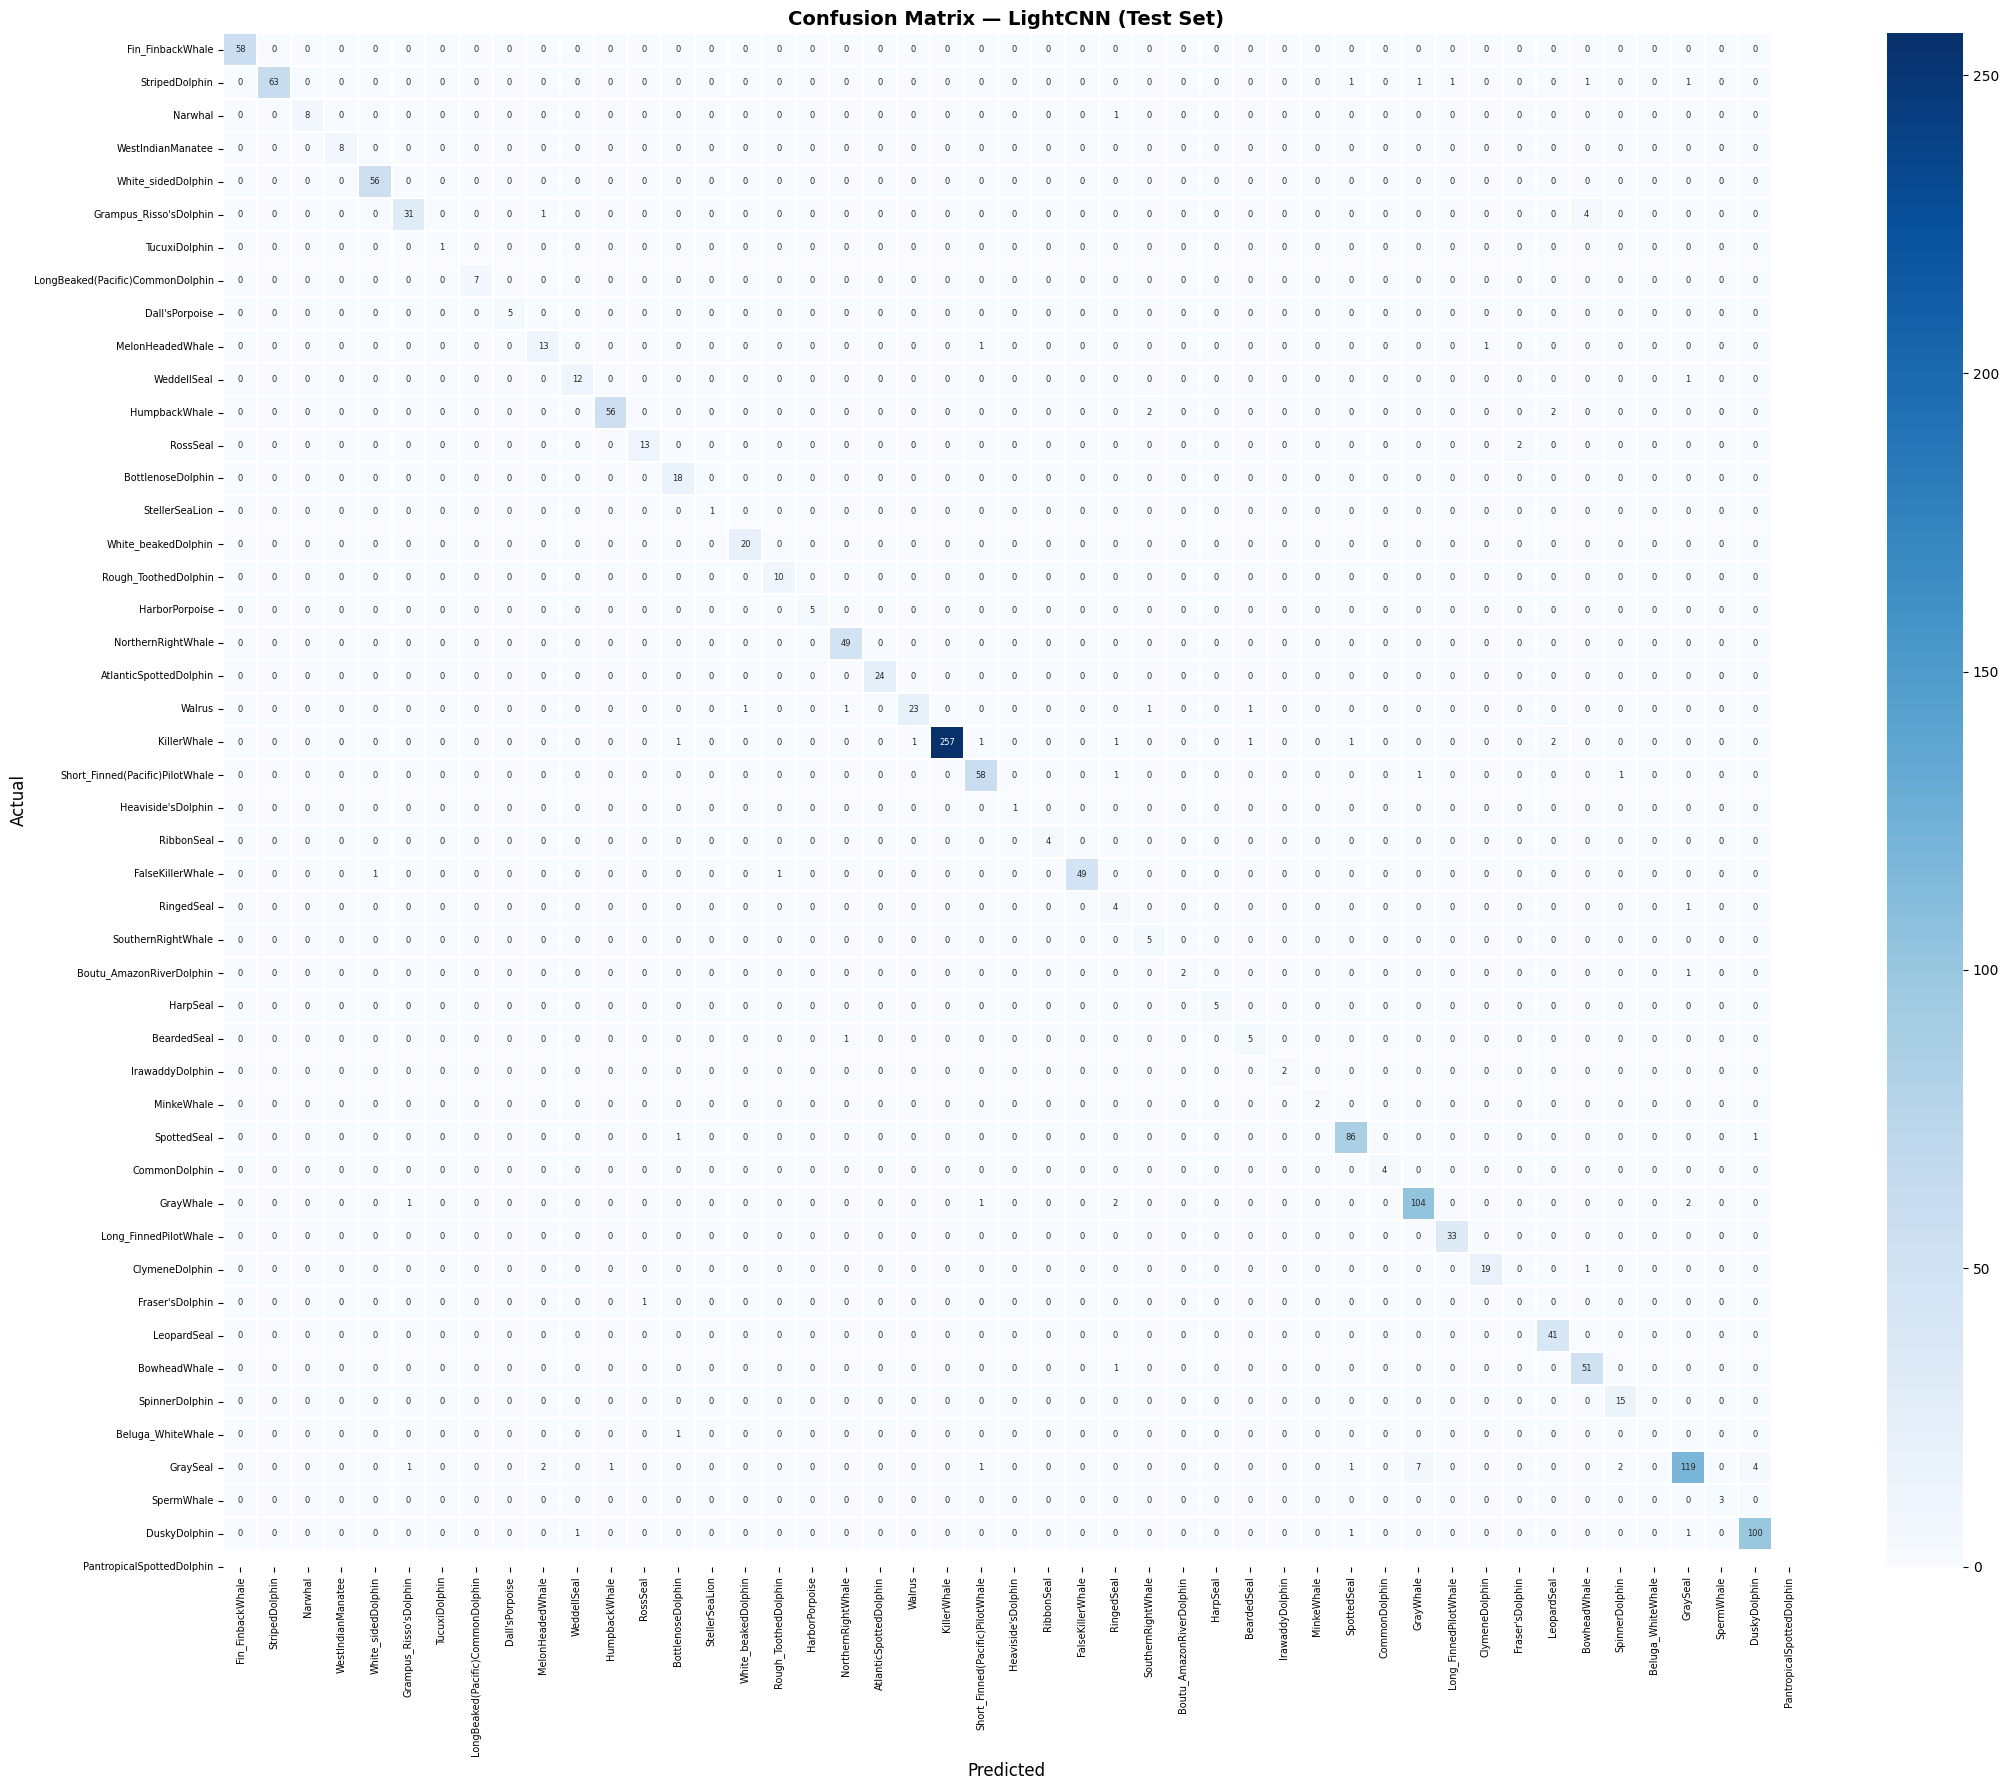


📋 Per-class Report — LightCNN:
                                  precision    recall  f1-score   support

                Fin_FinbackWhale       1.00      1.00      1.00        58
                  StripedDolphin       1.00      0.93      0.96        68
                         Narwhal       1.00      0.89      0.94         9
               WestIndianManatee       1.00      1.00      1.00         8
              White_sidedDolphin       0.98      1.00      0.99        56
          Grampus_Risso'sDolphin       0.94      0.86      0.90        36
                   TucuxiDolphin       1.00      1.00      1.00         1
LongBeaked(Pacific)CommonDolphin       1.00      1.00      1.00         7
                  Dall'sPorpoise       1.00      1.00      1.00         5
                MelonHeadedWhale       0.81      0.87      0.84        15
                     WeddellSeal       0.92      0.92      0.92        13
                   HumpbackWhale       0.98      0.93      0.96        60
     

In [21]:
best_dl_name = max(dl_results, key=lambda k: dl_results[k]['test_acc'])
res          = dl_results[best_dl_name]

cm = confusion_matrix(res['labels'], res['preds'])

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.3, annot_kws={'size': 6}
)
plt.title(f'Confusion Matrix — {best_dl_name} (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, f'confusion_matrix_{best_dl_name}.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'\n📋 Per-class Report — {best_dl_name}:')

print(classification_report(
    res['labels'], 
    res['preds'],
    labels=range(len(CLASS_NAMES)), 
    target_names=CLASS_NAMES, 
    zero_division=0
))

##  Cell 17 — SHAP Analysis (Best ML Model)

 SHAP Analysis for: Extra Trees


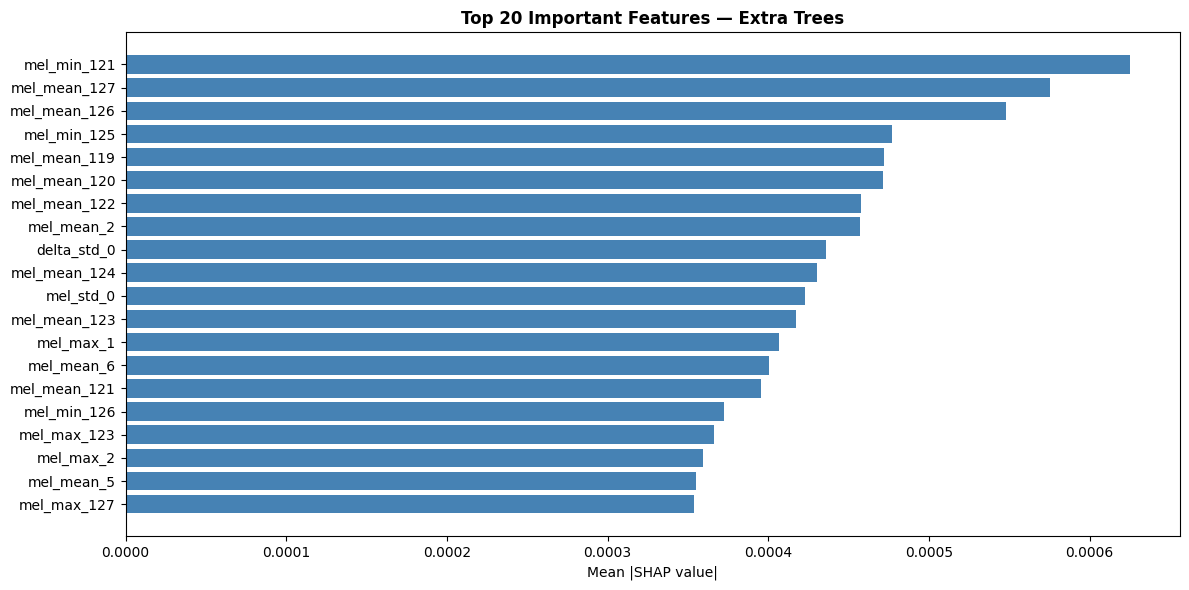

✅ SHAP analysis done!


In [22]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import os

best_ml_name = 'Extra Trees'   
best_clf     = ml_results[best_ml_name]['clf']
print(f' SHAP Analysis for: {best_ml_name}')

tree_models = ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'HistGradient Boosting']
shap_sample = X_test_ml[:100]  

if best_ml_name in tree_models:
    explainer  = shap.TreeExplainer(best_clf)
    shap_vals  = explainer.shap_values(shap_sample)
else:
    explainer = shap.KernelExplainer(best_clf.predict_proba, shap.sample(X_train_ml, 50))
    shap_vals = explainer.shap_values(shap_sample[:20], nsamples=50)

if hasattr(shap_vals, 'values'): 
    shap_vals = shap_vals.values

if isinstance(shap_vals, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
elif len(shap_vals.shape) == 3:
    mean_shap = np.abs(shap_vals).mean(axis=0).mean(axis=-1)
else:
    mean_shap = np.abs(shap_vals).mean(axis=0)

feat_names = (
    [f'mel_mean_{i}' for i in range(128)] +
    [f'mel_std_{i}'  for i in range(128)] +
    [f'mel_max_{i}'  for i in range(128)] +
    [f'mel_min_{i}'  for i in range(128)] +
    [f'delta_mean_{i}' for i in range(128)] +
    [f'delta_std_{i}'  for i in range(128)] +
    ['global_mean','global_std','global_max','global_min','global_skew','global_kurt']
)

top20_idx  = np.argsort(mean_shap)[-20:][::-1]

plt.figure(figsize=(12, 6))
plt.barh([feat_names[i] for i in top20_idx[::-1]],
          mean_shap[top20_idx[::-1]], color='steelblue')
plt.xlabel('Mean |SHAP value|')
plt.title(f'Top 20 Important Features — {best_ml_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ SHAP analysis done!')

##  Cell 18 — Predict on New .wav File

In [23]:
def predict_dl(wav_path, model_name='CustomCNN'):
    """Predict using a DL model"""
    ckpt_path = os.path.join(MODELS_DIR, f'{model_name}.pth')
    ckpt = torch.load(ckpt_path, weights_only=False)

    model_cls = {'CustomCNN': CustomCNN, 'ResidualCNN': ResidualCNN, 'LightCNN': LightCNN}
    model = model_cls[model_name](NUM_CLASSES).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    wav, sr = torchaudio.load(wav_path)
    if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
    if sr != SAMPLE_RATE: wav = T.Resample(sr, SAMPLE_RATE)(wav)
    tlen = SAMPLE_RATE * DURATION
    if wav.shape[1] < tlen: wav = wav.repeat(1, (tlen // wav.shape[1]) + 1)
    wav = wav[:, :tlen]
    mel = to_db(mel_transform(wav))
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    mel = mel.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(mel), dim=1)[0]
        top5  = probs.topk(5)

    print(f'\n🎵 [{model_name}] File: {os.path.basename(wav_path)}')
    print('─' * 55)
    for prob, idx in zip(top5.values, top5.indices):
        bar = '█' * int(prob.item() * 30)
        print(f'  {CLASS_NAMES[idx.item()]:40s} {prob.item()*100:5.1f}%  {bar}')

def predict_ml(wav_path, model_name=None):
    """Predict using the best ML model"""
    if model_name is None:
        model_name = max(ml_results, key=lambda k: ml_results[k]['test_acc'])
    clf = ml_results[model_name]['clf']

    wav, sr = torchaudio.load(wav_path)
    if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
    if sr != SAMPLE_RATE: wav = T.Resample(sr, SAMPLE_RATE)(wav)
    tlen = SAMPLE_RATE * DURATION
    if wav.shape[1] < tlen: wav = wav.repeat(1, (tlen // wav.shape[1]) + 1)
    wav = wav[:, :tlen]

    mel = to_db(mel_transform(wav))
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
    import tempfile
    with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as f:
        torch.save(mel, f.name)
        feat = extract_features(f.name)
    feat_scaled = scaler.transform(feat.reshape(1, -1))

    probs = clf.predict_proba(feat_scaled)[0]
    top5  = np.argsort(probs)[-5:][::-1]

    print(f'\n🤖 [{model_name}] File: {os.path.basename(wav_path)}')
    print('─' * 55)
    for idx in top5:
        bar = '█' * int(probs[idx] * 30)
        print(f'  {CLASS_NAMES[idx]:40s} {probs[idx]*100:5.1f}%  {bar}')

test_wav = file_list[0]
predict_dl(test_wav, 'CustomCNN')
predict_ml(test_wav)


🎵 [CustomCNN] File: 61025001.wav
───────────────────────────────────────────────────────
  AtlanticSpottedDolphin                    94.0%  ████████████████████████████
  Long_FinnedPilotWhale                      0.4%  
  Short_Finned(Pacific)PilotWhale            0.3%  
  Beluga_WhiteWhale                          0.3%  
  Rough_ToothedDolphin                       0.3%  

🤖 [SVM (RBF)] File: 61025001.wav
───────────────────────────────────────────────────────
  AtlanticSpottedDolphin                    94.0%  ████████████████████████████
  Beluga_WhiteWhale                          1.0%  
  Long_FinnedPilotWhale                      1.0%  
  WeddellSeal                                0.4%  
  WestIndianManatee                          0.3%  


##  Cell 19 — Final Summary Report

In [24]:
print('=' * 65)
print('  🐋 MARINE MAMMAL CLASSIFICATION — FINAL REPORT')
print('=' * 65)
print(f'  Dataset : Watkins WMMD')
print(f'  Files   : {len(file_list):,}  |  Classes: {NUM_CLASSES}')
print(f'  Split   : 75% train / 15% val / 10% test')
print('─' * 65)
print('  ML MODELS:')
for name, res in sorted(ml_results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'    {name:25s}  Test: {res["test_acc"]:5.2f}%  F1: {res["f1"]:5.2f}%')
print('─' * 65)
print('  DL MODELS:')
for name, res in sorted(dl_results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'    {name:25s}  Test: {res["test_acc"]:5.2f}%  F1: {res["f1"]:5.2f}%')
print('─' * 65)

all_test_accs = {**{k: v['test_acc'] for k, v in ml_results.items()},
                 **{k: v['test_acc'] for k, v in dl_results.items()}}
overall_best  = max(all_test_accs, key=all_test_accs.get)
print(f'  🥇 BEST MODEL: {overall_best}')
print(f'     Test Accuracy: {all_test_accs[overall_best]:.2f}%')
print('=' * 65)
print(f'\n📁 All figures saved to: {FIGURES_DIR}')
print(f'📁 All models  saved to: {MODELS_DIR}')
print(f'📊 MLflow UI: run  →  mlflow ui --backend-store-uri "{MLFLOW_URI}"')

  🐋 MARINE MAMMAL CLASSIFICATION — FINAL REPORT
  Dataset : Watkins WMMD
  Files   : 15,234  |  Classes: 47
  Split   : 75% train / 15% val / 10% test
─────────────────────────────────────────────────────────────────
  ML MODELS:
    SVM (RBF)                  Test: 91.86%  F1: 91.69%
    Extra Trees                Test: 89.17%  F1: 88.60%
    Random Forest              Test: 88.32%  F1: 87.73%
    Logistic Regression        Test: 85.24%  F1: 85.09%
    KNN                        Test: 80.84%  F1: 80.14%
    Linear Regression          Test: 77.23%  F1: 75.06%
    HistGradient Boosting      Test: 74.87%  F1: 75.87%
    Decision Tree              Test: 73.23%  F1: 73.05%
    Naive Bayes                Test: 36.48%  F1: 35.79%
─────────────────────────────────────────────────────────────────
  DL MODELS:
    LightCNN                   Test: 95.14%  F1: 95.22%
    CustomCNN                  Test: 94.95%  F1: 94.98%
    ResidualCNN                Test: 94.49%  F1: 94.53%
───────────────────